---
## 가산점 신청 (선택)

가산점을 받으려면 아래 항목 중 시도한 것을 체크하고, 해당 코드 셀 번호를 적어주세요.

### A. 알고리즘의 다양성
- 체크: O
- 해당 코드 셀: 5
- Logistic Regression, Linear SVM, Random Forest, Extra Trees, HistGradientBoosting을 비교했습니다.

### B. Hyperparameter 탐색의 다양성
- 체크: O
- 해당 코드 셀: 5
- 모델별 주요 hyperparameter를 RandomizedSearchCV로 탐색했습니다.

### C. 모델 성능 평가
- 체크: O
- 해당 코드 셀: 6, 7
- ROC-AUC, PR-AUC, Accuracy, Balanced Accuracy, F1, Precision, Recall을 함께 비교했습니다.

### D. 모델 개발 과정 시각화 및 설명
- 체크: O
- 해당 코드 셀: 7, 8
- 모델별 성능 막대그래프, confusion matrix, ROC curve, precision-recall curve, learning curve를 시각화했습니다.
---


# 기말고사 Template 2 — Machine Learning Model Pipeline

**이름:** __이나연__ &nbsp; **학번:** __20251258__

---

## 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 모델 저장 & 새 분자 예측** | 5점 | 모델을 저장한 후, 새로운 분자 구조를 예측할 수 있도록 정리. |

## 입력 / 출력
- **입력**: Template 1에서 만든 `final_dataset_descriptors.csv`
- **출력**:
  - `experiment_results.csv` — 모든 실험 결과 표
  - `experiment_best.csv` — 모델별 베스트만
  - `model_best.joblib` — 최고 모델 저장 파일
---


## 분석 전략

Template 1에서 만든 데이터는 급성 경구독성 데이터를 정리한 뒤 RDKit 2D descriptor와 Morgan fingerprint를 합친 이진분류용 데이터입니다. 이 노트북에서는 `label`을 target으로 두고, 화합물 이름/SMILES/측정값 같은 메타데이터 컬럼은 제외한 뒤 숫자형 descriptor만 feature로 사용합니다.

최종 모델은 단일 지표만 보지 않고 ROC-AUC와 PR-AUC를 중심으로 Accuracy, Balanced Accuracy, F1, Precision, Recall을 함께 비교해서 선택합니다.


In [2]:
# 1. 라이브러리 불러오기

# 비치명적 경고를 화면에 출력하지 않도록 설정
import warnings
warnings.filterwarnings('ignore')

# Path: 파일 경로를 다루기 위한 표준 라이브러리.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn.model_selection
#   train_test_split: 전체 데이터를 학습용/테스트용으로 분리
#   StratifiedKFold: 교차검증 시 클래스 비율(label 0/1 비율)을 유지하면서 데이터를 K개 fold로 나누는 방법
#   RandomizedSearchCV: 하이퍼파라미터 후보들을 무작위로 일정 개수만 뽑아서 탐색하는 기법
#   learning_curve: 학습 데이터 양을 점점 늘려가며 성능이 어떻게 변하는지 측정하는 도구
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve

# Pipeline: 전처리와 모델 학습을 하나의 객체로 묶어서 "fit 한 번"으로 전체 과정을 처리할 수 있게 해주는 도구.
#           cross-validation 시 fold마다 전처리를 새로 학습해야 하는데, Pipeline을 쓰면 이 과정이 자동으로 올바르게 처리됨.
from sklearn.pipeline import Pipeline

# SimpleImputer: 결측값을 특정 전략으로 채워주는 전처리기
from sklearn.impute import SimpleImputer

# StandardScaler: 각 feature를 평균 0, 표준편차 1로 맞춰주는 표준화 도구.
#                 거리/계수 기반 모델은 feature 간 단위 차이에 민감하므로 스케일링이 필요함.
from sklearn.preprocessing import StandardScaler

# VarianceThreshold: 분산이 0인 feature를 자동으로 제거해주는 전처리기.
#                    Morgan fingerprint처럼 비트가 많으면 항상 0이거나 항상 1인 비트가 섞여 있을 수 있어서 유용.
from sklearn.feature_selection import VarianceThreshold

# 모델 성능을 평가할 다양한 지표들
#   accuracy_score: 전체 중 맞춘 비율
#   balanced_accuracy_score: 클래스 불균형을 고려해 각 클래스별 정확도의 평균
#   f1_score: precision과 recall의 조화평균
#   precision_score: 양성으로 예측한 것 중 실제 양성인 비율
#   recall_score: 실제 양성 중 양성으로 맞춘 비율
#   roc_auc_score: ROC curve 아래 면적 (전체 threshold에서의 분류 성능)
#   average_precision_score: PR curve 아래 면적, 불균형 데이터에서 더 의미 있는 지표
#   ConfusionMatrixDisplay/RocCurveDisplay/PrecisionRecallDisplay: 각 평가 결과를 그래프로 그려주는 도구

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

# 이번 과제에서 비교할 5가지 분류 알고리즘
#   LogisticRegression: 선형 기반의 가장 기본적인 분류 모델
#   LinearSVC: 선형 SVM(Support Vector Machine) 분류기
#   RandomForestClassifier: 여러 decision tree를 조합한 모델
#   ExtraTreesClassifier: RandomForest와 비슷하지만 트리 분할 방식이 더 무작위적인 조합 모델
#   HistGradientBoostingClassifier: 히스토그램 기반의 빠른 gradient boosting 모델

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

# scipy.stats: 하이퍼파라미터를 무작위로 뽑을 때 사용할 확률분포들
#   randint: 정수 범위에서 균등하게 무작위 추출
#   uniform: 실수 범위에서 균등하게 무작위 추출
#   loguniform: 로그 스케일로 균등하게 무작위 추출

from scipy.stats import randint, uniform, loguniform

# joblib: 학습된 모델 객체를 파일로 저장하고 다시 불러오는 라이브러리.
#         pickle과 비슷하지만 numpy 배열이 많은 sklearn 모델 저장에 더 최적화되어 있음.
from joblib import dump, load

# RDKit은 Template 1에서 만든 RDKit 환경이 없을 수도 있으므로, try/except로 import 시도.
try:
    from rdkit import Chem, DataStructs, RDLogger
    from rdkit.Chem import Descriptors, AllChem
    RDLogger.DisableLog('rdApp.*')
    RDKIT_AVAILABLE = True
except Exception:
    RDKIT_AVAILABLE = False

# 실험 재현성을 위한 난수 시드.
# 같은 RANDOM_STATE를 쓰면 데이터 분할, 모델 초기화, RandomizedSearchCV의 무작위 탐색 결과가 항상 동일하게 재현됨.
RANDOM_STATE = 42

from matplotlib import font_manager, rc

# 폰트 파일 경로를 직접 지정해서 폰트 이름을 가져옴
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()

# matplotlib의 폰트 매니저에 이 폰트를 명시적으로 추가
font_manager.fontManager.addfont(font_path)

rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

print('실제 적용된 폰트 이름:', font_name)


sns.set_style('whitegrid')


실제 적용된 폰트 이름: Malgun Gothic


In [4]:
# 2. 데이터 불러오기

# 사용 자료
# 원본 엑셀: acute_oral.xlsx
# Template 1 완성 노트북: template1_acute_oral_pipeline.ipynb
# Template 1 출력 파일: final_dataset_descriptors.csv

# -------------------------------------------------------------------------
# [경로 안내 1]
# 해당 경로는 본인 노트북에서 테스트할 때 사용한 경로입니다. 
# -------------------------------------------------------------------------


# Template 1에서 만든 결과물을 이 노트북의 입력으로 사용
# Template 1과 Template 2는 파이프라인의 앞부분/뒷부분으로 서로 연결됨

source_excel_path = Path(r'C:\Users\elsan\Downloads\acute_oral.xlsx')
source_template1_path = Path(r'C:/Users/elsan/Downloads/template1_acute_oral_pipeline.ipynb')
input_path = Path(r'C:/Users/elsan/Downloads/final_dataset_descriptors.csv')
output_dir = Path(r'C:/Users/elsan/Downloads')


# =========================================================================
# [경로 안내 2 - 교수님] 
# 제 개인 노트북으로 실행했던 탓에 DS 경로가 설정되지 못했습니다.
# 교수님께서는 새로 셀들을 돌려보실 경우, 사용하시는 PC의 환경에 맞게 데이터 파일 경로를 지정해 주세요.
# 만약 본 노트북 파일과 데이터 파일들이 같은 폴더에 있다면, 아래 경로를 주석 제거 후(제가 사용한 경로는 주석 설정 후) 실행 부탁드립니다.
# =========================================================================

# source_excel_path = Path(r'acute_oral.xlsx')
# source_template1_path = Path(r'acute_oral_pipeline_template1.ipynb')
# input_path = Path(r'final_dataset_descriptors.csv')
# output_dir = Path(r'.')  # 현재 폴더에 결과 저장


# 세 경로가 실제로 존재하는지 미리 확인해서 출력.
# .exists(): 해당 경로에 파일이 실제로 있는지 True/False로 확인하는 Path 객체의 메서드.
# 어떤 파일이 빠졌는지 먼저 확인하기 위한 점검 코드.
for label_name, path in {
    '원본 엑셀': source_excel_path,
    'Template 1 노트북': source_template1_path,
    'Template 1 출력 CSV': input_path,
}.items():
    print(f'{label_name}: {path} / exists={path.exists()}')

# 이 노트북에서 실제로 필요한 파일은 input_path.
# 이 파일이 없으면 이후 코드를 실행해도 의미가 없으니 에러 메시지를 띄우고 중단.
if not input_path.exists():
    raise FileNotFoundError(
        'Template 2는 Template 1에서 생성한 final_dataset_descriptors.csv를 입력으로 사용합니다. '
        f'파일을 찾을 수 없습니다: {input_path}'
    )

df = pd.read_csv(input_path)

# 데이터 내의 무한대(inf, -inf) 값을 빈칸(NaN)으로 치환
# 아래 학습 파이프라인의 SimpleImputer가 무한대 값도 중앙값으로 채워짐

# [주의]

# 여기서 한 번 inf -> NaN 치환을 시도하지만, CSV를 막 읽어온 시점의 컬럼들은 아직 전부 숫자형으로 깔끔하게 인식되어 있다는 보장 없음.
# 만약 일부 값이 문자열 'inf'처럼 텍스트로 저장돼 있었다면 이 시점에는 잡히지 않고 다음 셀에서 pd.to_numeric으로 숫자 변환을 한 뒤 드러남.
# (다음 셀 주석에 [수정]이라고 표시된 부분이 이 문제를 다시 잡는 코드)
import numpy as np
df = df.replace([np.inf, -np.inf], np.nan)


print()
print('데이터 크기:', df.shape)
print('label 분포:')

# label(0/1)이 몇 개씩 있는지 확인-> 클래스 불균형 정도를 다시 한번 점검
display(df['label'].value_counts().sort_index().rename('count').to_frame())
display(df.head())


원본 엑셀: C:\Users\elsan\Downloads\acute_oral.xlsx / exists=True
Template 1 노트북: C:\Users\elsan\Downloads\template1_acute_oral_pipeline.ipynb / exists=False
Template 1 출력 CSV: C:\Users\elsan\Downloads\final_dataset_descriptors.csv / exists=True

데이터 크기: (7835, 2260)
label 분포:


,count
label,
0,3492
1,4343


,Chemical_Name,CASRN,SMILES,standardized_smi,Response,Response_Unit,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,Emetine dihydrochloride,316-42-7,Cl.Cl.[H][C@@]12C[C@H](C[C@H]3NCCC4=CC(OC)=C(O...,CC[C@H]1CN2CCc3cc(OC)c(OC)cc3[C@@H]2C[C@@H]1C[...,0.0120,mg/kg,1,5.676825,5.676825,0.345019,...,0,0,0,0,0,0,0,0,0,0
1,"2,3,7,8-Tetrachlorodibenzo-p-dioxin",1746-01-6,ClC1=C(Cl)C=C2OC3=CC(Cl)=C(Cl)C=C3OC2=C1,Clc1cc2c(cc1Cl)Oc1cc(Cl)c(Cl)cc1O2,0.0200,mg/kg,1,5.914545,5.914545,0.391229,...,0,0,0,0,0,0,0,0,0,0
2,Falecalcitriol [INN],83805-11-2,[H][C@@]1(CC[C@@]2([H])C(CCC[C@]12C)=CC=C1C[C@...,C=C1C(=CC=C2CCC[C@]3(C)[C@@H]([C@H](C)CCCC(O)(...,0.0417,mg/kg,1,13.011064,13.011064,0.077001,...,0,0,0,0,0,0,0,0,0,0
3,"2,3,7,8-Tetrabromodibenzo-p-dioxin",50585-41-6,BrC1=CC2=C(OC3=CC(Br)=C(Br)C=C3O2)C=C1Br,Brc1cc2c(cc1Br)Oc1cc(Br)c(Br)cc1O2,0.1000,mg/kg,1,5.822407,5.822407,0.686849,...,0,0,0,0,0,0,0,0,0,0
4,Sodium fluoroacetate,62-74-8,[Na+].[O-]C(=O)CF,O=C([O-])CF,0.1000,mg/kg,1,10.453704,10.453704,1.388889,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# 3. Feature/target 분리 및 학습/테스트 데이터 분할
# 화합물 식별자와 원 측정값은 feature에서 제외하고, 숫자형 descriptor/fingerprint만 사용
import numpy as np

# target_col: 모델이 맞춰야 하는 정답 컬럼
target_col = 'label'

# metadata_cols: 화합물을 '식별'하기 위한 정보이거나, label을 만들 때 이미 사용된
# 원본 측정값들. 이 컬럼들은 화학적 특성이 아니라 식별자/정답 관련 정보이므로 모델의 입력 feature로 쓰면 안 됨.
#   - SMILES, standardized_smi, Chemical_Name, CASRN: 화합물을 구분하는 이름표 역할. 숫자형 화학적 특성이 아니므로 feature가 될 수 없음.
#   - Response, Response_Unit: label을 만든 원본 LD50 수치 자체. 이걸 feature로 넣으면 정보 유출 발생.
metadata_cols = ['Chemical_Name', 'CASRN', 'SMILES', 'standardized_smi', 'Response', 'Response_Unit', target_col]

# 전체 컬럼 중 metadata_cols에 포함되지 않은 나머지 = RDKit 2D descriptor + Morgan fingerprint 컬럼들
feature_cols = [c for c in df.columns if c not in metadata_cols]

# [수정] 1) 먼저 숫자로 변환.

#   문자열로 섞여 있던 'inf' / 'Infinity' / '-inf' 같은 값은 바로 이 시점에 진짜 무한대(np.inf)로 바뀜.
#   pd.to_numeric(..., errors='coerce'): 숫자로 바꿀 수 없는 값은 에러 대신 NaN으로 처리.
#   .apply(...)를 통해 feature_cols의 모든 컬럼에 한 번에 적용.
X = df[feature_cols].apply(pd.to_numeric, errors='coerce')

# [수정] 2) 숫자 변환이 끝난 이후에 inf를 NaN으로 바꿈.

#   기존 코드는 df 단계(문자열 상태)에서 미리 inf를 제거했기 때문에,
#   바로 다음 줄의 pd.to_numeric()이 문자열 inf를 다시 진짜 inf로 만들어내면서 무한대가 되살아남.
#   즉 inf 제거 -> 숫자 변환의 순서가 잘못되어 있었고, 여기서는 그 순서를 숫자 변환 -> inf 제거로 바로잡음. 변환 과정에서 새로 생겨난 inf까지 확인.
X = X.replace([np.inf, -np.inf], np.nan)

# [수정] 3) RandomForest 등 트리 계열 모델은 내부적으로 float32를 사용한다.

#   진짜 inf가 아니어도 float32 표현 범위를 넘는 거대한 값이 있으면 predict 단계에서 같은 에러 발생.
#   np.finfo(np.float32).max: float32가 표현할 수 있는 가장 큰 값을 가져옴
#   X.mask(조건, np.nan): 조건이 True인 위치의 값을 np.nan으로 바꿔주는 함수
#   (float32 한계를 넘는 비정상적으로 큰 값들도 결측치로 처리해서 모델이 깨지지 않게 미리 막음)
FLOAT32_MAX = np.finfo(np.float32).max
X = X.mask(X.abs() > FLOAT32_MAX, np.nan)

# 정답 컬럼은 정수형으로 명확히 지정
y = df[target_col].astype(int)

# 위 과정을 거치면 모든 값이 NaN이 되어버린 컬럼이 있을 수 있다.
# X.isna().all(): 컬럼별로 모든 행이 NaN인지 확인 -> 제거
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    X = X.drop(columns=all_nan_cols)
    feature_cols = X.columns.tolist()

# 깨끗해진 X 데이터로 학습/테스트 데이터를 분할.
# train_test_split:
#   test_size=0.2: 전체의 20%를 테스트셋으로, 나머지 80%를 학습셋으로 분리
#   random_state=RANDOM_STATE: 항상 동일하게 분할되도록 시드 고정
#   stratify=y: label의 0/1 비율을 train/test 양쪽에서 원본과 동일하게 유지

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Feature 개수:', len(feature_cols))
print('Train/Test:', X_train.shape, X_test.shape)

# stratify가 잘 작동했는지 확인하기 위해 train/test 각각의 양성 비율 출력
print('Train label 비율:', round(y_train.mean(), 4))
print('Test label 비율:', round(y_test.mean(), 4))


Feature 개수: 2253
Train/Test: (6268, 2253) (1567, 2253)
Train label 비율: 0.5542
Test label 비율: 0.5546


In [6]:
# 4. 공통 평가 함수 정의
# 5가지 모델 모두에 동일한 방식으로 성능을 평가하기 위해, 평가 과정을 함수 하나로 통일

def evaluate_classifier(name, fitted_model, X_test, y_test):
    # 학습이 끝난 모델로 테스트 데이터의 클래스를 예측
    pred = fitted_model.predict(X_test)

    # ROC-AUC, PR-AUC 같은 지표는 확률 점수가 필요, 모델마다 확률을 직접 주는 방식이 다르므로 셋 중 하나를 상황에 맞게 사용.
    if hasattr(fitted_model, 'predict_proba'):
        # predict_proba가 있는 모델(LogisticRegression, RandomForest 등):
        # [:, 1] -> 클래스 1(독성)일 확률만 추출
        score = fitted_model.predict_proba(X_test)[:, 1]
    elif hasattr(fitted_model, 'decision_function'):
        # LinearSVC처럼 확률 대신 결정 경계로부터의 거리만 제공하는 모델은 그 값을 점수로 대신 사용(값이 클수록 클래스 1에 더 가까움)
        score = fitted_model.decision_function(X_test)
    else:
        # 둘 다 없는 경우 예측 클래스 자체를 점수로 사용
        score = pred

    # 평가지표들을 한 번에 계산해서 딕셔너리로 반환.
    # 단일 지표만 보지 않고 여러 지표를 함께 비교하는 이유는 지표마다 강조하는 측면이 다르기 때문
    return {
        'model': name,
        'test_roc_auc': roc_auc_score(y_test, score),               # 전체 threshold에서의 분류 능력
        'test_pr_auc': average_precision_score(y_test, score),      # 양성 클래스 예측 품질, 불균형 데이터에 더 적합
        'test_accuracy': accuracy_score(y_test, pred),              # 전체 정확도
        'test_balanced_accuracy': balanced_accuracy_score(y_test, pred),  # 클래스별 정확도의 평균(불균형 보정)
        'test_f1': f1_score(y_test, pred),                          # precision/recall의 조화평균
        
        # zero_division=0: 만약 모델이 한 클래스를 전혀 예측하지 않아서 분모가 0이 되는 경우, 에러 대신 0으로 처리
        'test_precision': precision_score(y_test, pred, zero_division=0),
        'test_recall': recall_score(y_test, pred, zero_division=0),
    }

# 교차검증에 사용할 분할 방식 정의.
# StratifiedKFold(n_splits=3): 데이터를 3개의 fold로 나누되, 각 fold에서도 label 0/1 비율이 원본과 비슷하게 유지되도록 함.
# shuffle=True: fold를 나누기 전에 데이터를 무작위로 섞음 (원래 순서에 패턴이 있을 경우의 편향 방지)
# random_state=RANDOM_STATE: 재현성을 위한 시드 고정
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


In [7]:
# 5-1. 공통 pipeline 및 탐색 설정 함수

# 공통 전처리: 결측값 중앙값 대체 + 분산 0 feature 제거
# 선형/SVM 계열은 scale에 민감하므로 StandardScaler를 포함

# 어떤 모델이든 동일한 전처리 단계를 거쳐서 학습할 수 있도록 묶어주는 함수.
# Pipeline으로 만들어두면 cross-validation의 각 fold마다 "imputer/scaler를 train 데이터에만 fit하고 test에는 적용만 하는"
# 과정이 자동으로 올바르게 처리되어, data leakage 방지.
def make_pipeline(model, scale=False):
    steps = [
        # 1단계: 결측치를 각 컬럼의 중앙값으로 채움.
        #   중앙값: 이상치의 영향을 덜 받아서 더 안정적인 대체값이 됨.
        ('imputer', SimpleImputer(strategy='median')),
        # 2단계: 분산이 0인 feature를 제거.
        #   특히 Morgan fingerprint 중에는 데이터셋 전체에서 항상 0이거나 1인 비트가 섞여 있을 수 있어서 해당 단계 유용.
        ('variance', VarianceThreshold()),
    ]
    # scale=True인 경우에만 표준화 단계를 추가.
    # LogisticRegression, LinearSVC처럼 계수 기반/거리 기반 모델은 feature 단위 차이에 민감하지만,
    # RandomForest 같은 트리 기반 모델은 어차피 각 feature를 기준값과 비교하는 방식이라 scale에 영향을 받지 않으므로 생략 가능.
    if scale:
        steps.append(('scaler', StandardScaler()))
    # 마지막 단계로 실제 분류 모델을 추가
    steps.append(('model', model))
    return Pipeline(steps)


# RandomForest, ExtraTrees 같은 트리 기반 앙상블 모델들이 공통으로 사용할 하이퍼파라미터 탐색 범위를 정의하는 함수
def tree_search_params():
    return {
        # model__n_estimators: 앙상블에 포함할 트리의 개수. 100~250 사이에서 정수로 무작위 추출.
        'model__n_estimators': randint(100, 250),
        
        # model__max_depth: 각 트리가 가질 수 있는 최대 깊이. None은 제한 없음을 의미.
        #   깊이가 깊을수록 데이터를 더 세밀하게 학습하지만 과적합 위험도 커짐.
        'model__max_depth': [None, 8, 12, 20],
        
        # model__min_samples_split: 노드를 더 나누기 위해 필요한 최소 샘플 수
        'model__min_samples_split': randint(2, 10),
        
        # model__min_samples_leaf: 마지막 끝 노드가 가져야 하는 최소 샘플 수. 값이 클수록 트리가 더 단순해지고 과적합이 줄어듦.
        'model__min_samples_leaf': randint(1, 5),
        
        # model__max_features: 각 분기마다 고려할 feature의 개수를 제한하는 방식.
        #   'sqrt': feature 개수의 제곱근만큼만 고려, 'log2': 로그값만큼만 고려.
        #   feature가 매우 많을 때 트리마다 다른 feature 일부만 보게 해서 다양성을 높이고 과적합을 줄이는 효과.
        'model__max_features': ['sqrt', 'log2'],
    }


In [8]:
# 5-2. 알고리즘별 hyperparameter 탐색 공간

# 5가지 알고리즘 각각에 대해, 어떤 pipeline을 쓸지 + 어떤 하이퍼파라미터 범위를 탐색할지를 하나의 딕셔너리(search_spaces)로 정리
# 이렇게 모아두면 다음 셀에서 for문으로 5개 모델을 한 번에 순회하며 학습/탐색할 수 있어서 코드 중복을 줄임

# [설계 의도 1] 왜 n_iter=6인가?

# RandomizedSearchCV는 n_iter * cv.n_splits번 모델을 학습함.
# 여기서는 cv가 3-fold이므로 모델 1개당 6*3 = 18번의 학습이 발생, 5개 모델 전체로는 90번의 학습이 발생함.
# RandomForest/ExtraTrees/HistGradientBoosting처럼 트리를 100~250개씩 묶는 앙상블 모델은 한 번 학습하는 데 시간이 걸리기 때문에,
# n_iter를 너무 크게 잡으면 노트북 전체 실행 시간이 크게 늘어남.
# 6이라는 값은 하이퍼파라미터 탐색을 아예 안 하는 것(n_iter=1)과 촘촘하게 다 탐색하는 것(n_iter=30~50) 사이에서
# 제한된 시간 안에 그래도 몇 가지 조합을 비교해보기 위해 선택한 방법.

# [설계 의도 2] 왜 일부 모델에만 class_weight='balanced'를 주는가?

# label 0(저독성)과 1(독성)의 비율이 정확히 반반이 아니라 불균형하기 때문에,
# 모델이 그냥 다수 클래스만 예측해도 정확도가 높게 나오는 함정을 피하기 위해
# class_weight='balanced' 옵션으로 소수 클래스의 오분류에 더 큰 비중을 둠

# LogisticRegression, LinearSVC, RandomForest, ExtraTrees는 이 옵션을 직접 지원하므로 모두 동일하게 적용.
# 반면 HistGradientBoostingClassifier는 scikit-learn에서 class_weight 파라미터 자체를 제공하지 않는 모델이라 적용하지 않음.
# 일관성 누락 x, 이 모델만 그 옵션이 존재하지 않기 때문임.

search_spaces = {
    'LogisticRegression': {
        # scale=True: 선형 모델은 feature 단위 차이에 민감하므로 표준화 필수
        'pipeline': make_pipeline(
            # max_iter=3000: 수렴(최적화 완료)까지 충분한 반복 횟수를 보장
            # class_weight='balanced': label 0/1 비율이 불균형할 때,
            # 적은 쪽 클래스의 오분류에 더 큰 가중치를 줘서 모델이 다수 클래스만 맞추는 쪽으로 치우치지 않게 함.
            LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
            scale=True,
        ),
        'params': {
            # model__C: 정규화 강도의 역수. 값이 클수록 정규화가 약해짐(복잡한 모델, 과적합 위험 증가).
            #   loguniform(1e-3, 1e2): 0.001~100 사이를 로그 스케일로 고르게 탐색
            'model__C': loguniform(1e-3, 1e2),
            'model__penalty': ['l2'],     # L2 정규화 고정
            'model__solver': ['lbfgs'],   # 최적화 알고리즘 고정
        },
        # n_iter=6: RandomizedSearchCV가 위 파라미터 조합을 6번만 무작위로 뽑아서 시도
        #   (계산 시간을 절약하기 위해 일부만 샘플링)
        'n_iter': 6,
    },
    'SVM_Linear': {
        'pipeline': make_pipeline(
            # class_weight='balanced': 위와 동일하게 불균형 보정
            # max_iter=5000: SVM도 충분한 반복 안에서 수렴하도록 여유 있게 설정
            LinearSVC(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
            scale=True,
        ),
        'params': {
            'model__C': loguniform(1e-3, 1e2),   # SVM의 마진 폭을 조절하는 정규화 파라미터
            'model__loss': ['squared_hinge'],     # 기본 손실 함수 고정
        },
        'n_iter': 6,
    },
    'RandomForest': {
        # 트리 기반 모델은 scale에 영향받지 않으므로 scale=True를 생략(기본값 False)
        'pipeline': make_pipeline(RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
        # n_jobs=-1: 사용 가능한 모든 CPU 코어를 동원해서 병렬로 학습 (속도 향상)
        'params': tree_search_params(),   # 앞서 정의한 공통 트리 하이퍼파라미터 재사용
        'n_iter': 6,
    },
    'ExtraTrees': {
        'pipeline': make_pipeline(ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
        'params': tree_search_params(),
        'n_iter': 6,
    },
    'HistGradientBoosting': {
        # class_weight 옵션이 없는 모델이라 따로 지정하지 않음
        # (위 [설계 의도 2]에서 설명했듯, HistGradientBoostingClassifier는
        # scikit-learn 구현상 class_weight 파라미터 자체가 없으므로 생략이 아니라 불가능에 해당)
        'pipeline': make_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
        'params': {
            # model__learning_rate: 한 번에 얼마나 크게 학습할지(boosting step 크기). 작을수록 안정적이지만 더 많은 반복 필요.
            'model__learning_rate': loguniform(0.01, 0.2),
            
            # model__max_iter: boosting 반복(트리 추가) 횟수
            'model__max_iter': randint(100, 200),
            
            # model__max_leaf_nodes: 각 트리가 가질 수 있는 최대 리프 노드 수(트리 복잡도 제한)
            'model__max_leaf_nodes': randint(15, 63),
            
            # model__l2_regularization: 과적합을 줄이기 위한 L2 정규화 강도
            'model__l2_regularization': uniform(0.0, 1.0),
        },
        'n_iter': 6,
    },
}


In [9]:
# 6. 하이퍼파라미터 탐색 수행, 결과 저장 및 최종 모델 선택

# [핵심 추가] 모델별 RandomizedSearchCV 학습 및 성능 평가
search_objects = {}        # 모델 이름 -> 학습이 끝난 RandomizedSearchCV 객체를 저장할 딕셔너리
best_models_summary = []   # 모델별 테스트 성능 평가 결과(딕셔너리)들을 모아둘 리스트

# search_spaces에 정의된 5개 모델(LogisticRegression, SVM_Linear, RandomForest, ExtraTrees, HistGradientBoosting)을
# 순서대로 하나씩 꺼내서 동일한 절차로 처리
for model_name, space in search_spaces.items():
    # RandomizedSearchCV: 정의된 파라미터 범위 안에서 n_iter개의 조합을 무작위로 뽑아서
    # cross-validation으로 각각 평가, 가장 좋은 조합을 자동으로 찾아줌.
    search = RandomizedSearchCV(
        estimator=space['pipeline'],          # 전처리+모델이 합쳐진 pipeline
        param_distributions=space['params'],  # 탐색할 하이퍼파라미터 범위
        n_iter=space['n_iter'],                # 몇 개 조합을 시도할지
        scoring='roc_auc',                     # 어떤 지표를 기준으로 best를 판단할지
        cv=cv,                                  # 앞서 정의한 StratifiedKFold(3-fold) 교차검증
        random_state=RANDOM_STATE,             # 무작위 탐색 결과 재현을 위한 시드
        n_jobs=-1                               # 모든 CPU 코어 사용해서 병렬 처리
    )
    # 실제로 train 데이터에 대해 탐색을 수행. 내부적으로 n_iter * cv.n_splits번 모델을 학습함.
    search.fit(X_train, y_train)
    # 이 모델의 탐색 결과를 딕셔너리에 저장
    search_objects[model_name] = search
    
    # 4번 셀의 평가 함수로 테스트 결과 수집
    # search.best_estimator_: 탐색 중 가장 좋았던 하이퍼파라미터 조합으로 최종 학습된 pipeline
    # 한 번도 보지 않은 X_test/y_test에 적용해서 진짜 성능 평가
    eval_metrics = evaluate_classifier(model_name, search.best_estimator_, X_test, y_test)
    best_models_summary.append(eval_metrics)

# test_roc_auc 기준 최고 모델이 0번 인덱스에 오도록 정렬
# best_models_summary를 DataFrame으로 변환한 뒤 test_roc_auc 컬럼 기준 내림차순으로 정렬
experiment_best = pd.DataFrame(best_models_summary).sort_values(by='test_roc_auc', ascending=False).reset_index(drop=True)


# [기존 코드] 최종 모델 선택 및 파일 저장
# 정렬된 표의 0번 행(=ROC-AUC가 가장 높은 모델)의 이름을 최종 선택 모델로 결정
best_model_name = experiment_best.loc[0, 'model']
best_search = search_objects[best_model_name]      # 해당 모델의 RandomizedSearchCV 객체
best_model = best_search.best_estimator_            # 그 안에서 가장 좋은 하이퍼파라미터로 학습된 pipeline

# 5개 모델 각각의 모든 하이퍼파라미터 조합 시도 결과를 하나의 표로 합치는 과정.
# cv_results_에는 시도한 각 파라미터 조합의 평균 점수, 표준편차, 순위 등이 모두 들어있음
# 탐색 과정 전체를 기록으로 남김.
all_results = []
for name, search in search_objects.items():
    cv_results = pd.DataFrame(search.cv_results_)
    # 어떤 모델의 결과인지 구분할 수 있도록 'model' 컬럼을 맨 앞에 추가
    cv_results.insert(0, 'model', name)
    all_results.append(cv_results)
    
# 5개 모델의 결과 표들을 위아래로(행 기준) 이어붙여서 하나의 큰 표로 합침
experiment_results = pd.concat(all_results, ignore_index=True)

# 결과를 CSV로 저장
experiment_results_path = output_dir / 'experiment_results.csv'  # 모든 시도 조합의 상세 결과
experiment_best_path = output_dir / 'experiment_best.csv'        # 모델별 best 결과만 정리한 요약표
experiment_results.to_csv(experiment_results_path, index=False, encoding='utf-8-sig')
experiment_best.to_csv(experiment_best_path, index=False, encoding='utf-8-sig')

print('최종 선택 모델:', best_model_name)
display(experiment_best)


최종 선택 모델: RandomForest


,model,test_roc_auc,test_pr_auc,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall
0,RandomForest,0.868680,0.890314,0.781749,0.774467,0.810421,0.781818,0.841197
1,HistGradientBoosting,0.867624,0.890246,0.774729,0.768701,0.802241,0.781659,0.823936
2,ExtraTrees,0.861421,0.886923,0.776005,0.771966,0.800228,0.791667,0.808976
3,LogisticRegression,0.802638,0.820018,0.733248,0.730033,0.759494,0.759494,0.759494
4,SVM_Linear,0.771018,0.784740,0.710274,0.707346,0.737572,0.740999,0.734177


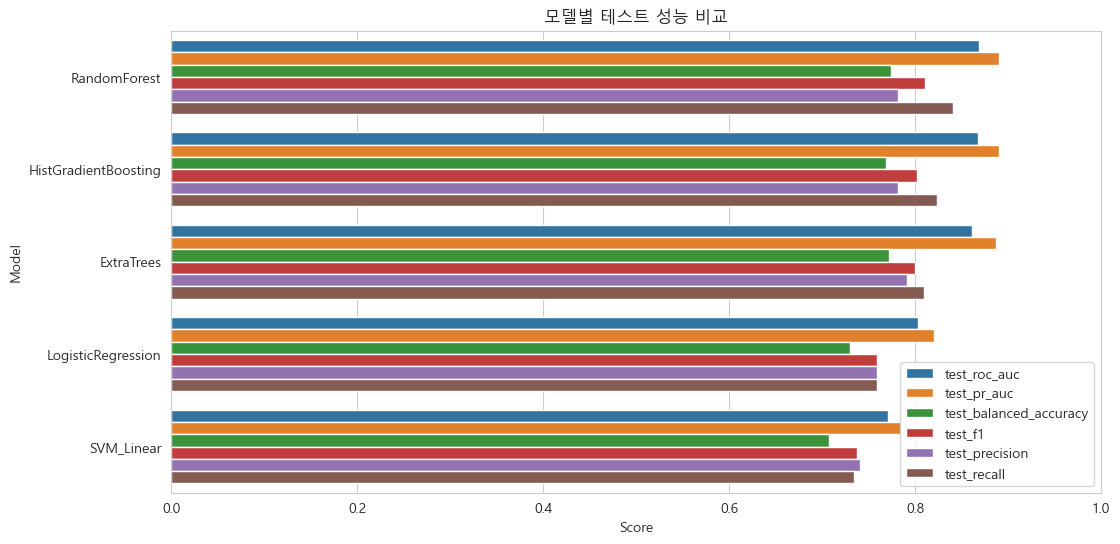

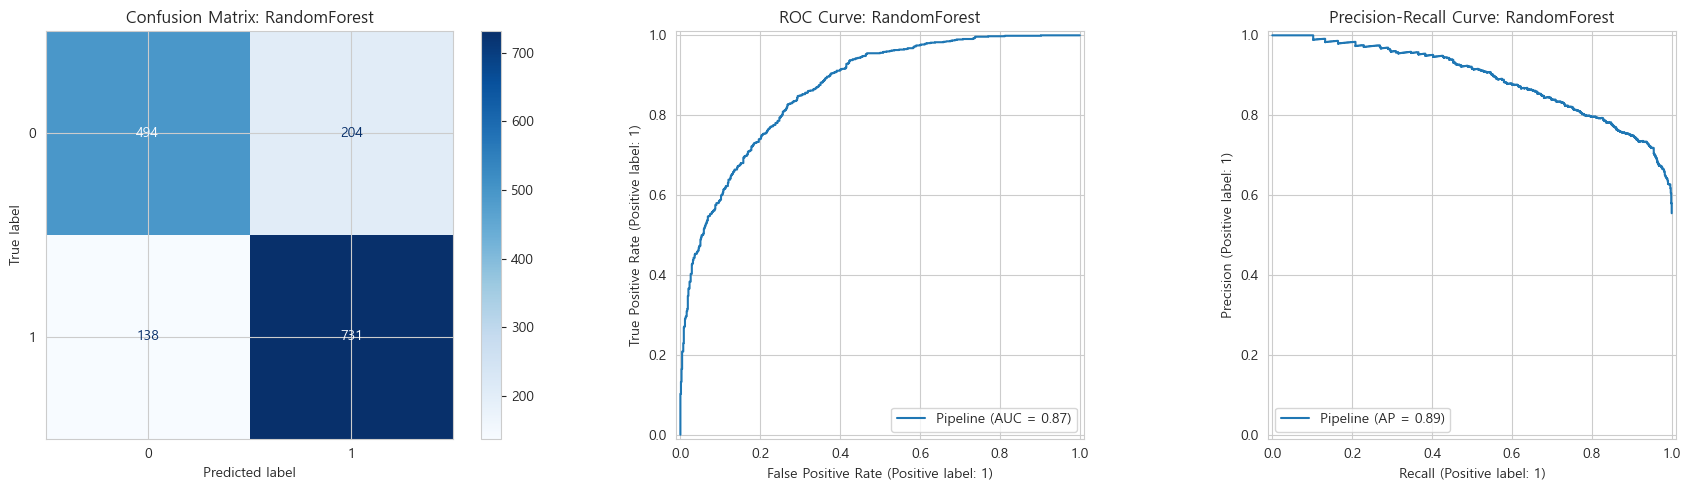

In [10]:
# 7. 모델 성능 시각화

from matplotlib import rc
rc('font', family='Malgun Gothic')   # 폰트를 리셋했을 수 있으므로 그래프 그리기 직전에 재설정
plt.rcParams['axes.unicode_minus'] = False


# 막대그래프로 비교할 핵심 지표들을 선택 (정확도는 불균형 데이터에서 왜곡되기 쉬워 제외, 균형잡힌 지표들 위주로 시각화)
metric_cols = ['test_roc_auc', 'test_pr_auc', 'test_balanced_accuracy', 'test_f1', 'test_precision', 'test_recall']

# .melt(): "model, metric1, metric2, ..." 형태의 표를 "model, metric, score" 형태로 바꿔주는 함수.
#   seaborn의 barplot은 이렇게 long format일 때 hue(색 구분)를 쓰기 편함.
#   id_vars='model': model 컬럼은 그대로 유지
#   value_vars=metric_cols: 이 컬럼들을 'metric'과 'score'로 풀어서 펼침
plot_df = experiment_best.melt(id_vars='model', value_vars=metric_cols, var_name='metric', value_name='score')

plt.figure(figsize=(12, 6))

# x=score, y=model, hue=metric: 모델별로 6개 지표의 점수를 그룹 막대로 비교
sns.barplot(data=plot_df, x='score', y='model', hue='metric')

plt.xlim(0, 1)   # 모든 지표가 0~1 범위이므로 x축을 0~1로 고정해서 비교가 쉽게
plt.title('모델별 테스트 성능 비교')
plt.xlabel('Score')
plt.ylabel('Model')
plt.legend(loc='lower right')
plt.show()

# 최종 선택된 모델 하나에 대해서만 3개의 추가 시각화를 나란히 표시
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix: 실제 0/1과 예측 0/1의 조합별 개수를 표로 보여줌
#   (예: 실제 독성인데 저독성으로 잘못 예측한 경우가 몇 건인지 등 구체적인 오류 패턴 확인)
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix: {best_model_name}')

# ROC Curve: 분류 threshold를 0~1로 바꿔가며 True Positive Rate vs False Positive Rate를 그린 곡선.
#   -> 곡선이 왼쪽 위에 가까울수록 분류 성능이 좋음
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title(f'ROC Curve: {best_model_name}')

# Precision-Recall Curve: threshold를 바꿔가며 Precision vs Recall의 변화를 그린 곡선.
#   -> 불균형 데이터(label 1이 적은 경우)에서는 ROC curve보다 이 곡선이 모델 성능을 더 솔직하게 보여주는 경우가 많음

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=axes[2])
axes[2].set_title(f'Precision-Recall Curve: {best_model_name}')
plt.tight_layout()
plt.show()


,train_size,train_mean,train_std,valid_mean,valid_std
0,417,1.000000,0.000000,0.763349,0.014664
1,1357,0.999922,0.000061,0.814957,0.005478
2,2297,0.999743,0.000114,0.833765,0.002869
3,3237,0.999349,0.000150,0.844106,0.001377
4,4178,0.998710,0.000142,0.850268,0.003834


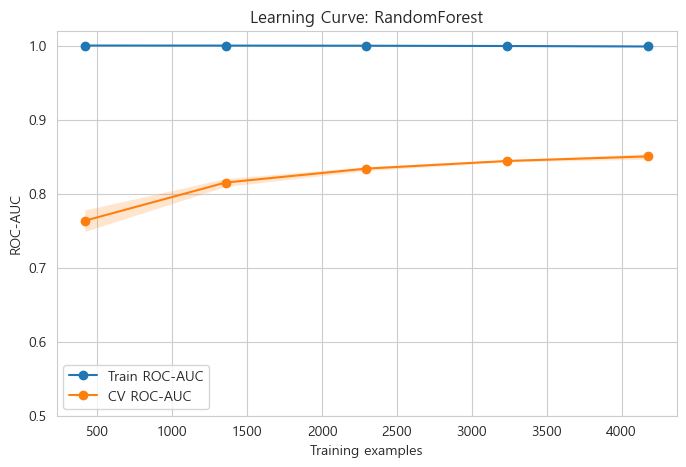

In [11]:
# 8. Learning curve로 모델 개발 과정 시각화
# learning_curve: 학습 데이터의 양을 점점 늘려가면서, 그때마다 train 점수와 cross-validation 점수가 어떻게 변하는지 측정.

train_sizes, train_scores, valid_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    # train_sizes=np.linspace(0.1, 1.0, 5):
    #   학습 데이터를 전체의 10%, 32.5%, 55%, 77.5%, 100%)만큼씩 사용해서 각 지점마다 모델을 새로 학습하고 성능을 측정
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# train_scores, valid_scores는 (train_sizes 개수, cv fold 개수) 모양의 2차원 배열이므로,
# 각 학습 데이터 크기에서 fold들의 평균과 표준편차를 계산해서 표로 정리
lc_df = pd.DataFrame({
    'train_size': train_sizes,
    'train_mean': train_scores.mean(axis=1),
    'train_std': train_scores.std(axis=1),
    'valid_mean': valid_scores.mean(axis=1),
    'valid_std': valid_scores.std(axis=1),
})

display(lc_df)

plt.figure(figsize=(8, 5))
# train 점수 곡선 (모델이 학습에 사용한 데이터 자체를 얼마나 잘 맞추는지)
plt.plot(lc_df['train_size'], lc_df['train_mean'], marker='o', label='Train ROC-AUC')

# fill_between: 평균 +- 표준편차 범위를 반투명하게. fold마다 점수가 얼마나 분산했는지 시각적으로 표현
plt.fill_between(lc_df['train_size'], lc_df['train_mean'] - lc_df['train_std'], lc_df['train_mean'] + lc_df['train_std'], alpha=0.2)

# cross-validation 점수 곡선(학습에 쓰지 않은 데이터에 대한 일반화 성능)
plt.plot(lc_df['train_size'], lc_df['valid_mean'], marker='o', label='CV ROC-AUC')
plt.fill_between(lc_df['train_size'], lc_df['valid_mean'] - lc_df['valid_std'], lc_df['valid_mean'] + lc_df['valid_std'], alpha=0.2)
plt.title(f'Learning Curve: {best_model_name}')
plt.xlabel('Training examples')
plt.ylabel('ROC-AUC')
plt.ylim(0.5, 1.02)   # ROC-AUC는 0.5(무작위 추측)~1.0(완벽) 사이. 그 범위로 y축 고정
plt.legend()
plt.show()


In [12]:
# 9. 최종 모델 저장
# 새 분자 예측에 필요한 feature 목록까지 함께 저장함.

# 모델 객체 하나만 저장하면 나중에 다시 쓸 때 어떤 컬럼 순서로 입력해야 하는지, 어떤 모델이었는지 등의 맥락 정보가 사라짐.
# 모델과 함께 필요한 부가 정보를 하나의 딕셔너리로 묶어서 저장.
# 나중에 불러올 때 새로운 SMILES를 동일한 형식의 feature로 만들어 예측할 수 있게 됨.

model_bundle = {
    'model': best_model,                          # 학습이 끝난 최종 pipeline(전처리+모델)
    'feature_cols': feature_cols,                 # 학습에 사용된 feature 컬럼 이름과 순서
    'metadata_cols': metadata_cols,                # 참고용: 제외했던 메타데이터 컬럼 목록
    'best_model_name': best_model_name,            # 선택된 모델의 이름
    'best_params': best_search.best_params_,        # 탐색을 통해 찾은 최적 하이퍼파라미터
    'input_path': str(input_path)                  # 어떤 데이터로 학습했는지 출처 기록
}

model_path = output_dir / 'model_best.joblib'
# joblib.dump: 위 딕셔너리를 파일로 직렬화(저장)
dump(model_bundle, model_path)
print('모델 저장 완료:', model_path)


모델 저장 완료: C:\Users\elsan\Downloads\model_best.joblib


In [13]:
# 10-1. 새 분자 SMILES feature 생성 함수
# Template 1과 같은 방식으로 RDKit 2D descriptor + Morgan fingerprint를 만듦.


def smiles_to_descriptor_row(smiles):
    # 사용자가 입력한 SMILES 문자열을 RDKit 분자 객체로 변환 시도
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # 변환에 실패하면 명확한 에러를 발생시켜 사용자가 입력을 다시 확인하게 함
        raise ValueError(f'유효하지 않은 SMILES입니다: {smiles}')
    # Template 1과 동일하게 CalcMolDescriptors로 2D descriptor를 계산,
    # 한 줄짜리 DataFrame으로 만들어서 반환 (mol 객체도 같이 반환 -> fingerprint 계산에 재사용)
    return mol, pd.DataFrame([Descriptors.CalcMolDescriptors(mol)])


def morgan_fingerprint_df(mol, radius=2, n_bits=2048):
    # Template 1과 동일한 radius/n_bits로 Morgan fingerprint 계산
    # (radius, n_bits가 학습 때와 다르면 비트의 의미가 달라져서 모델이 잘못 해석. 반드시 일치 필요)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return pd.DataFrame([arr], columns=[f'morgan_{i}' for i in range(n_bits)])


def make_feature_row_from_smiles(smiles, feature_cols, radius=2, n_bits=2048):
    # RDKit이 없는 환경에서는 새 SMILES feature 생성이 불가능하므로 미리 막음
    if not RDKIT_AVAILABLE:
        raise ImportError('RDKit이 설치되어 있어야 새 SMILES 예측을 할 수 있습니다.')

    mol, desc_df = smiles_to_descriptor_row(smiles)
    fp_df = morgan_fingerprint_df(mol, radius=radius, n_bits=n_bits)
    
    # 2D descriptor 표와 fingerprint 표를 옆으로 이어붙여서 하나의 feature 행으로 합침.
    # 혹시 descriptor 계산에서 inf가 나올 경우를 대비해 NaN으로 치환
    
    row = pd.concat([desc_df, fp_df], axis=1).replace([np.inf, -np.inf], np.nan)
    
    # reindex(columns=feature_cols): 모델이 학습할 때 사용한 컬럼 순서와 정확히 동일한 순서/구성으로 맞춰줌.
    # 컬럼 순서가 다르면 모델이 엉뚱한 값을 엉뚱한 feature로 해석하게 됨.
    
    return row.reindex(columns=feature_cols)


In [14]:
# 10-2. 저장된 모델로 독성 예측

def model_positive_probability(model, X_new, pred):
    
    # predict_proba가 있는 모델은 클래스 1일 확률을 그대로 사용
    
    if hasattr(model, 'predict_proba'):
        return float(model.predict_proba(X_new)[0, 1])
        
    # LinearSVC처럼 확률을 직접 주지 않는 모델은 decision_function 값을 시그모이드 함수로 0~1 사이 값으로 변환해 확률처럼 사용
    #   1 / (1 + exp(-x)) 형태의 시그모이드 변환
    
    if hasattr(model, 'decision_function'):
        raw = float(model.decision_function(X_new)[0])
        return 1 / (1 + np.exp(-raw))
        
    # 둘 다 없으면 예측 클래스값(0 또는 1) 자체를 그대로 반환
    return float(pred)


def predict_toxicity_from_smiles(smiles, model_bundle_path=model_path):
    
    # 저장해둔 model_bundle을 다시 불러옴
    bundle = load(model_bundle_path)
    
    # 학습 때와 동일한 방식/순서로 새 SMILES의 feature를 생성
    X_new = make_feature_row_from_smiles(smiles, bundle['feature_cols'])
    model_saved = bundle['model']
    
    # 학습된 모델로 0 또는 1 클래스를 예측
    pred = int(model_saved.predict(X_new)[0])

    return {
        'smiles': smiles,
        'predicted_label': pred,
        'predicted_class': '고독성 / LD50 <= 2000 mg/kg' if pred == 1 else '저독성 / LD50 > 2000 mg/kg',
        'probability_label_1': model_positive_probability(model_saved, X_new, pred),
    }

# 예: caffeine (카페인의 SMILES로 실제 동작을 확인)
example = predict_toxicity_from_smiles('Cn1cnc2c1c(=O)n(C)c(=O)n2C')
example


{'smiles': 'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
 'predicted_label': 1,
 'predicted_class': '고독성 / LD50 <= 2000 mg/kg',
 'probability_label_1': 0.8288199184331096}

## 최종 해석

최종 모델은 테스트 ROC-AUC와 PR-AUC가 가장 높은 모델로 선택했습니다. ROC-AUC는 전체 threshold에서 양성/음성을 구분하는 능력을 보여주고, PR-AUC는 양성 클래스 예측 품질을 더 직접적으로 보여줍니다. Confusion matrix로 실제 오분류 양상을 확인했고, learning curve를 통해 학습 데이터가 증가할 때 train score와 validation score가 어떻게 변하는지 확인했습니다.

저장된 model_best.joblib에는 모델뿐 아니라 학습에 사용한 feature 순서가 함께 들어 있으므로, 새 SMILES를 같은 descriptor/fingerprint 형식으로 변환한 뒤 바로 예측할 수 있습니다.


Learning curve를 보면 train ROC-AUC는 학습 데이터 크기와 거의 무관하게 1.0에 가깝게 유지되는 반면, validation ROC-AUC는 0.76에서 0.85까지 학습 데이터가 늘어남에 따라 꾸준히 상승하는 패턴을 보입니다. 이는 RandomForest처럼 복잡도가 높은 트리 기반 앙상블 모델이 train 데이터에 거의 완벽히 적합하는 경향 때문이며, 일반적으로 나타나는 특성입니다.

다만 validation score가 학습 데이터가 늘어날수록 계속 개선되고 있다는 점은 데이터가 더 늘어나면 train-validation 격차가 줄어들 가능성을 시사하며, 현재 시점에서 과적합이 심각한 수준은 아니라고 판단했습니다.
